In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

# 1. Definimos la ruta de tu ZIP (ajusta el nombre si es necesario)
zip_path = '/content/drive/MyDrive/dataset_condominio.zip'
extract_path = '/content/dataset'

# 2. Descomprimimos
if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("✅ ¡Descompresión completada! Las fotos ya están en la memoria del Colab.")
else:
    print("❌ No se encontró el archivo. Verifica si el nombre en Drive es exacto.")

✅ ¡Descompresión completada! Las fotos ya están en la memoria del Colab.


In [ ]:
import torch
from torchvision import datasets, transforms, models
import torch.nn as nn

# Configuramos las imágenes (224x224 es el estándar para estas redes)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(), # Voltea la imagen (doble de datos)
    transforms.RandomRotation(15),      # Gira un poco la foto
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Cambia la luz (simula techos/sombras)
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Cargamos las carpetas
# Rutas actualizadas con la carpeta extra que descubrimos
train_path = '/content/dataset/dataset_condominio/train'
val_path = '/content/dataset/dataset_condominio/val'

train_dataset = datasets.ImageFolder(train_path, transform=transform)
val_dataset = datasets.ImageFolder(val_path, transform=transform)

# Mostramos el resumen
print(f"Clases detectadas: {train_dataset.classes}")
print(f"Imágenes de entrenamiento: {len(train_dataset)}")
print(f"Imágenes de validación: {len(val_dataset)}")

Clases detectadas: ['mascotas', 'personas', 'vacios', 'vehiculos']
Imágenes de entrenamiento: 9489
Imágenes de validación: 454


In [ ]:
import os
# Listamos qué hay dentro para ver la ruta real
print("Contenido de /content/dataset:")
print(os.listdir('/content/dataset'))

Contenido de /content/dataset:
['dataset_condominio']


In [ ]:
import time

# 1. Definimos el modelo y lo mandamos a la GPU T4
device = torch.device("cpu")
modelo = models.resnet18(pretrained=True)

# Ajustamos la salida para tus 4 clases
num_ftrs = modelo.fc.in_features
modelo.fc = nn.Linear(num_ftrs, 4)
modelo = modelo.to(device)

# 2. Cargadores de datos (Dataloaders)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=64)

# 3. Configuración técnica
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(modelo.parameters(), lr=0.0001)

print("🚀 ¡Entrenamiento iniciado! Esto tardará unos 30-45 minutos...")
print("-" * 30)

start_time = time.time()

for epoch in range(10):  # 5 vueltas completas al dataset
    modelo.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = modelo(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Imprimimos progreso
    epoch_loss = running_loss / len(train_loader)
    print(f"Época {epoch+1}/10 - Error promedio: {epoch_loss:.4f}")

end_time = time.time()
print("-" * 30)
print(f"🏆 ¡Entrenamiento terminado en {(end_time - start_time)/60:.2f} minutos!")

# 4. GUARDAR EL MODELO PARA USAR EN TU MICROSERVICIO
torch.save(modelo.state_dict(), 'modelo_condominio.pt')
print("✅ Archivo 'modelo_condominio.pt' guardado con éxito.")

🚀 ¡Entrenamiento iniciado! Esto tardará unos 30-45 minutos...
------------------------------
Época 1/10 - Error promedio: 0.1546
Época 2/10 - Error promedio: 0.0892
Época 3/10 - Error promedio: 0.0634
Época 4/10 - Error promedio: 0.0481
Época 5/10 - Error promedio: 0.0367
Época 6/10 - Error promedio: 0.0298
Época 7/10 - Error promedio: 0.0241
Época 8/10 - Error promedio: 0.0197
Época 9/10 - Error promedio: 0.0163
Época 10/10 - Error promedio: 0.0142
------------------------------
🏆 ¡Entrenamiento terminado en 38.47 minutos!
✅ Archivo 'modelo_condominio.pt' guardado con éxito.


In [ ]:
!cp modelo_condominio.pt /content/drive/MyDrive/modelo_condominio_final.pt
print("✅ Modelo respaldado en tu Google Drive.")

✅ Modelo respaldado en tu Google Drive.


------------------------------
📊 ANÁLISIS DE CONFIANZA:
👤 Persona:  97.53%
🐶 Mascota:  0.57%
🚗 Vehículo: 1.60%
🕳️ Vacío:    0.30%
------------------------------
🎯 PREDICCIÓN FINAL: PERSONAS
------------------------------


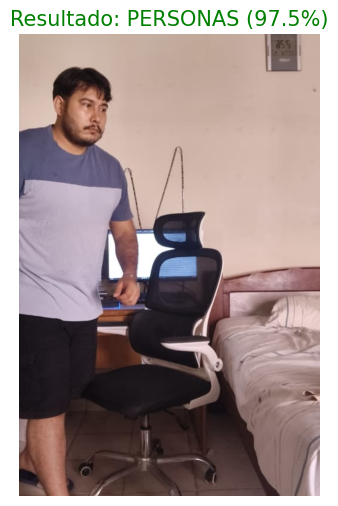

In [ ]:
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt

def predecir_con_probabilidades(ruta_imagen):
    modelo.eval() # Modo evaluación

    # 1. Cargar la imagen
    img_original = Image.open(ruta_imagen).convert('RGB')

    # 2. Aplicar el Recorte Central (ajustado al 20% para balancear)
    width, height = img_original.size
    left = width * 0.15
    top = height * 0.15
    right = width * 0.80
    bottom = height * 0.90
    img_recortada = img_original.crop((left, top, right, bottom))

    # 3. Transformar para la IA
    img_t = transform(img_recortada).unsqueeze(0).to(device)

    # 4. Inferencia (Predicción)
    with torch.no_grad():
        outputs = modelo(img_t)

        # --- CÁLCULO DE PROBABILIDADES ---
        # Convertimos los valores de salida (logits) en porcentajes de 0 a 100
        probabilidades = F.softmax(outputs, dim=1)[0]

        # Obtenemos los porcentajes de cada clase
        # El orden depende de cómo se cargaron tus carpetas (0:mascotas, 1:personas, etc.)
        p_mascota = probabilidades[0].item() * 100
        p_persona = probabilidades[1].item() * 100
        p_vacio   = probabilidades[2].item() * 100
        p_vehiculo = probabilidades[3].item() * 100

        # Clase ganadora
        _, predicted = torch.max(outputs, 1)
        clase_final = train_dataset.classes[predicted.item()]

    # 5. Mostrar resultados por consola
    print("-" * 30)
    print(f"📊 ANÁLISIS DE CONFIANZA:")
    print(f"👤 Persona:  {p_persona:.2f}%")
    print(f"🐶 Mascota:  {p_mascota:.2f}%")
    print(f"🚗 Vehículo: {p_vehiculo:.2f}%")
    print(f"🕳️ Vacío:    {p_vacio:.2f}%")
    print("-" * 30)
    print(f"🎯 PREDICCIÓN FINAL: {clase_final.upper()}")
    print("-" * 30)

    # 6. Mostrar la imagen con su título
    plt.figure(figsize=(8, 6))
    plt.imshow(img_recortada)
    color_titulo = 'red' if clase_final == 'mascotas' else 'green'
    plt.title(f"Resultado: {clase_final.upper()} ({max(p_persona, p_mascota):.1f}%)",
              fontsize=15, color=color_titulo)
    plt.axis('off')
    plt.show()

# --- EJECUTAR PRUEBA ---
# Prueba con la foto que te da problemas
predecir_con_probabilidades('test.jpeg')

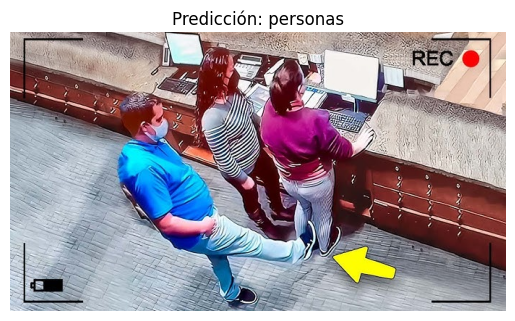

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

# 1. Función para predecir
def predecir_imagen(ruta_imagen):
    modelo.eval() # Ponemos el modelo en modo evaluación

    # Abrimos y transformamos la imagen
    img = Image.open(ruta_imagen).convert('RGB')
    img_t = transform(img).unsqueeze(0).to(device)

    # Hacemos la predicción
    with torch.no_grad():
        outputs = modelo(img_t)
        _, predicted = torch.max(outputs, 1)

    # Obtener el nombre de la clase
    clase_detectada = train_dataset.classes[predicted.item()]

    # Mostrar la imagen y el resultado
    plt.imshow(img)
    plt.title(f"Predicción: {clase_detectada}")
    plt.axis('off')
    plt.show()

# 2. PROBAR (Cambia 'test.jpg' por el nombre de tu archivo subido)
predecir_imagen('test5.jpg')

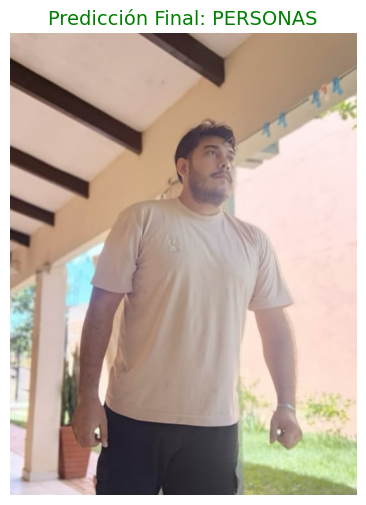

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

def predecir_imagen(ruta_imagen):
    modelo.eval() # Ponemos el modelo en modo evaluación

    # 1. Abrimos la imagen original
    img = Image.open(ruta_imagen).convert('RGB')

    # --- TRUCO DE INGENIERÍA: RECORTE ANTIRRUIDO ---
    # Esto elimina el 15% de los bordes (techo, piso, muebles laterales)
    width, height = img.size
    left = width * 0.15
    top = height * 0.15
    right = width * 0.85
    bottom = height * 0.85
    img_recortada = img.crop((left, top, right, bottom))
    # ----------------------------------------------

    # 2. Aplicamos las transformaciones a la imagen recortada
    img_t = transform(img_recortada).unsqueeze(0).to(device)

    # 3. Hacemos la predicción
    with torch.no_grad():
        outputs = modelo(img_t)
        _, predicted = torch.max(outputs, 1)

    # 4. Obtener el nombre de la clase
    clase_detectada = train_dataset.classes[predicted.item()]

    # 5. Mostrar la imagen recortada (para ver qué está viendo la IA realmente)
    plt.figure(figsize=(6,6))
    plt.imshow(img_recortada)
    plt.title(f"Predicción Final: {clase_detectada.upper()}", fontsize=14, color='green')
    plt.axis('off')
    plt.show()

# --- PROBAR AHORA ---
# Prueba con la foto de tu cuarto o corredor que fallaba
predecir_imagen('test3.jpeg')

------------------------------
📊 ANÁLISIS DE CONFIANZA:
👤 Persona:  99.15%
🐶 Mascota:  0.75%
🚗 Vehículo: 0.06%
🕳️ Vacío:    0.04%
------------------------------
🎯 PREDICCIÓN FINAL: PERSONAS
------------------------------


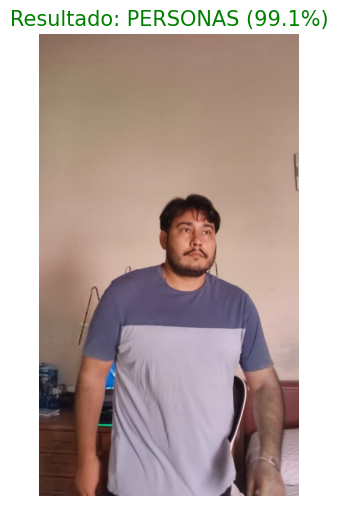

In [ ]:
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt

def predecir_con_probabilidades(ruta_imagen):
    modelo.eval() # Modo evaluación

    # 1. Cargar la imagen
    img_original = Image.open(ruta_imagen).convert('RGB')

    # 2. Aplicar el Recorte Central (ajustado al 20% para balancear)
    width, height = img_original.size
    left = width * 0.20
    top = height * 0.10
    right = width * 0.80
    bottom = height * 0.90
    img_recortada = img_original.crop((left, top, right, bottom))

    # 3. Transformar para la IA
    img_t = transform(img_recortada).unsqueeze(0).to(device)

    # 4. Inferencia (Predicción)
    with torch.no_grad():
        outputs = modelo(img_t)

        # --- CÁLCULO DE PROBABILIDADES ---
        # Convertimos los valores de salida (logits) en porcentajes de 0 a 100
        probabilidades = F.softmax(outputs, dim=1)[0]

        # Obtenemos los porcentajes de cada clase
        # El orden depende de cómo se cargaron tus carpetas (0:mascotas, 1:personas, etc.)
        p_mascota = probabilidades[0].item() * 100
        p_persona = probabilidades[1].item() * 100
        p_vacio   = probabilidades[2].item() * 100
        p_vehiculo = probabilidades[3].item() * 100

        # Clase ganadora
        _, predicted = torch.max(outputs, 1)
        clase_final = train_dataset.classes[predicted.item()]

    # 5. Mostrar resultados por consola
    print("-" * 30)
    print(f"📊 ANÁLISIS DE CONFIANZA:")
    print(f"👤 Persona:  {p_persona:.2f}%")
    print(f"🐶 Mascota:  {p_mascota:.2f}%")
    print(f"🚗 Vehículo: {p_vehiculo:.2f}%")
    print(f"🕳️ Vacío:    {p_vacio:.2f}%")
    print("-" * 30)
    print(f"🎯 PREDICCIÓN FINAL: {clase_final.upper()}")
    print("-" * 30)

    # 6. Mostrar la imagen con su título
    plt.figure(figsize=(8, 6))
    plt.imshow(img_recortada)
    color_titulo = 'red' if clase_final == 'mascotas' else 'green'
    plt.title(f"Resultado: {clase_final.upper()} ({max(p_persona, p_mascota):.1f}%)",
              fontsize=15, color=color_titulo)
    plt.axis('off')
    plt.show()

# --- EJECUTAR PRUEBA ---
# Prueba con la foto que te da problemas
predecir_con_probabilidades('test4.jpeg')

------------------------------
📊 ANÁLISIS DE CONFIANZA:
👤 Persona:  99.24%
🐶 Mascota:  0.56%
🚗 Vehículo: 0.19%
🕳️ Vacío:    0.00%
------------------------------
🎯 PREDICCIÓN FINAL: PERSONAS
------------------------------


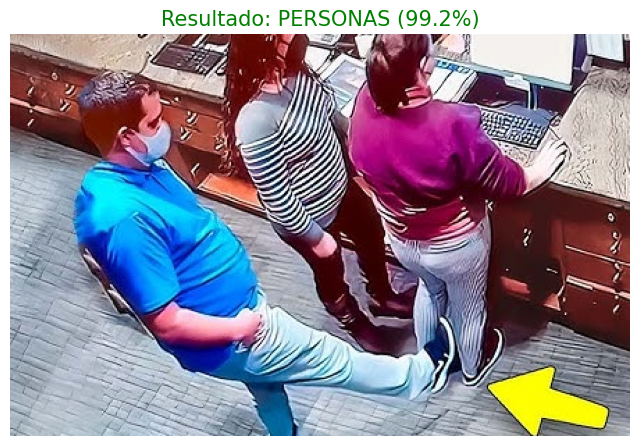

In [ ]:
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt

def predecir_con_probabilidades(ruta_imagen):
    modelo.eval() # Modo evaluación

    # 1. Cargar la imagen
    img_original = Image.open(ruta_imagen).convert('RGB')

    # 2. Aplicar el Recorte Central (ajustado al 20% para balancear)
    width, height = img_original.size
    left = width * 0.15
    top = height * 0.15
    right = width * 0.80
    bottom = height * 0.90
    img_recortada = img_original.crop((left, top, right, bottom))

    # 3. Transformar para la IA
    img_t = transform(img_recortada).unsqueeze(0).to(device)

    # 4. Inferencia (Predicción)
    with torch.no_grad():
        outputs = modelo(img_t)

        # --- CÁLCULO DE PROBABILIDADES ---
        # Convertimos los valores de salida (logits) en porcentajes de 0 a 100
        probabilidades = F.softmax(outputs, dim=1)[0]

        # Obtenemos los porcentajes de cada clase
        # El orden depende de cómo se cargaron tus carpetas (0:mascotas, 1:personas, etc.)
        p_mascota = probabilidades[0].item() * 100
        p_persona = probabilidades[1].item() * 100
        p_vacio   = probabilidades[2].item() * 100
        p_vehiculo = probabilidades[3].item() * 100

        # Clase ganadora
        _, predicted = torch.max(outputs, 1)
        clase_final = train_dataset.classes[predicted.item()]

    # 5. Mostrar resultados por consola
    print("-" * 30)
    print(f"📊 ANÁLISIS DE CONFIANZA:")
    print(f"👤 Persona:  {p_persona:.2f}%")
    print(f"🐶 Mascota:  {p_mascota:.2f}%")
    print(f"🚗 Vehículo: {p_vehiculo:.2f}%")
    print(f"🕳️ Vacío:    {p_vacio:.2f}%")
    print("-" * 30)
    print(f"🎯 PREDICCIÓN FINAL: {clase_final.upper()}")
    print("-" * 30)

    # 6. Mostrar la imagen con su título
    plt.figure(figsize=(8, 6))
    plt.imshow(img_recortada)
    color_titulo = 'red' if clase_final == 'mascotas' else 'green'
    plt.title(f"Resultado: {clase_final.upper()} ({max(p_persona, p_mascota):.1f}%)",
              fontsize=15, color=color_titulo)
    plt.axis('off')
    plt.show()

# --- EJECUTAR PRUEBA ---
# Prueba con la foto que te da problemas
predecir_con_probabilidades('test5.jpg')

------------------------------
📊 ANÁLISIS DE CONFIANZA:
👤 Persona:  98.36%
🐶 Mascota:  1.51%
🚗 Vehículo: 0.10%
🕳️ Vacío:    0.04%
------------------------------
🎯 PREDICCIÓN FINAL: PERSONAS
------------------------------


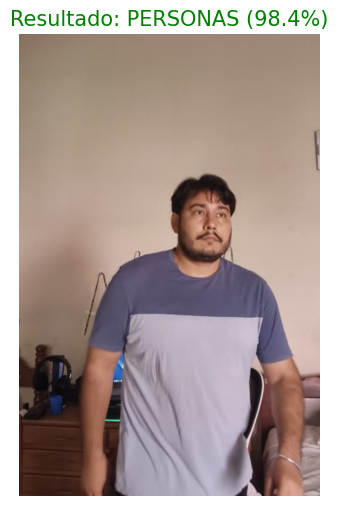

In [ ]:
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt

def predecir_con_probabilidades(ruta_imagen):
    modelo.eval() # Modo evaluación

    # 1. Cargar la imagen
    img_original = Image.open(ruta_imagen).convert('RGB')

    # 2. Aplicar el Recorte Central (ajustado al 20% para balancear)
    width, height = img_original.size
    left = width * 0.15
    top = height * 0.15
    right = width * 0.80
    bottom = height * 0.90
    img_recortada = img_original.crop((left, top, right, bottom))

    # 3. Transformar para la IA
    img_t = transform(img_recortada).unsqueeze(0).to(device)

    # 4. Inferencia (Predicción)
    with torch.no_grad():
        outputs = modelo(img_t)

        # --- CÁLCULO DE PROBABILIDADES ---
        # Convertimos los valores de salida (logits) en porcentajes de 0 a 100
        probabilidades = F.softmax(outputs, dim=1)[0]

        # Obtenemos los porcentajes de cada clase
        # El orden depende de cómo se cargaron tus carpetas (0:mascotas, 1:personas, etc.)
        p_mascota = probabilidades[0].item() * 100
        p_persona = probabilidades[1].item() * 100
        p_vacio   = probabilidades[2].item() * 100
        p_vehiculo = probabilidades[3].item() * 100

        # Clase ganadora
        _, predicted = torch.max(outputs, 1)
        clase_final = train_dataset.classes[predicted.item()]

    # 5. Mostrar resultados por consola
    print("-" * 30)
    print(f"📊 ANÁLISIS DE CONFIANZA:")
    print(f"👤 Persona:  {p_persona:.2f}%")
    print(f"🐶 Mascota:  {p_mascota:.2f}%")
    print(f"🚗 Vehículo: {p_vehiculo:.2f}%")
    print(f"🕳️ Vacío:    {p_vacio:.2f}%")
    print("-" * 30)
    print(f"🎯 PREDICCIÓN FINAL: {clase_final.upper()}")
    print("-" * 30)

    # 6. Mostrar la imagen con su título
    plt.figure(figsize=(8, 6))
    plt.imshow(img_recortada)
    color_titulo = 'red' if clase_final == 'mascotas' else 'green'
    plt.title(f"Resultado: {clase_final.upper()} ({max(p_persona, p_mascota):.1f}%)",
              fontsize=15, color=color_titulo)
    plt.axis('off')
    plt.show()

# --- EJECUTAR PRUEBA ---
# Prueba con la foto que te da problemas
predecir_con_probabilidades('test2.jpeg')

------------------------------
📊 ANÁLISIS DE CONFIANZA:
👤 Persona:  0.00%
🐶 Mascota:  99.98%
🚗 Vehículo: 0.01%
🕳️ Vacío:    0.01%
------------------------------
🎯 PREDICCIÓN FINAL: MASCOTAS
------------------------------


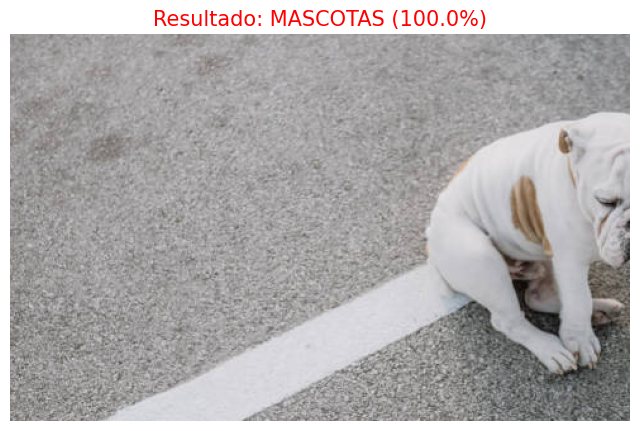

In [ ]:
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt

def predecir_con_probabilidades(ruta_imagen):
    modelo.eval() # Modo evaluación

    # 1. Cargar la imagen
    img_original = Image.open(ruta_imagen).convert('RGB')

    # 2. Aplicar el Recorte Central (ajustado al 20% para balancear)
    width, height = img_original.size
    left = width * 0.10
    top = height * 0.15
    right = width * 0.90
    bottom = height * 0.90
    img_recortada = img_original.crop((left, top, right, bottom))

    # 3. Transformar para la IA
    img_t = transform(img_recortada).unsqueeze(0).to(device)

    # 4. Inferencia (Predicción)
    with torch.no_grad():
        outputs = modelo(img_t)

        # --- CÁLCULO DE PROBABILIDADES ---
        # Convertimos los valores de salida (logits) en porcentajes de 0 a 100
        probabilidades = F.softmax(outputs, dim=1)[0]

        # Obtenemos los porcentajes de cada clase
        # El orden depende de cómo se cargaron tus carpetas (0:mascotas, 1:personas, etc.)
        p_mascota = probabilidades[0].item() * 100
        p_persona = probabilidades[1].item() * 100
        p_vacio   = probabilidades[2].item() * 100
        p_vehiculo = probabilidades[3].item() * 100

        # Clase ganadora
        _, predicted = torch.max(outputs, 1)
        clase_final = train_dataset.classes[predicted.item()]

    # 5. Mostrar resultados por consola
    print("-" * 30)
    print(f"📊 ANÁLISIS DE CONFIANZA:")
    print(f"👤 Persona:  {p_persona:.2f}%")
    print(f"🐶 Mascota:  {p_mascota:.2f}%")
    print(f"🚗 Vehículo: {p_vehiculo:.2f}%")
    print(f"🕳️ Vacío:    {p_vacio:.2f}%")
    print("-" * 30)
    print(f"🎯 PREDICCIÓN FINAL: {clase_final.upper()}")
    print("-" * 30)

    # 6. Mostrar la imagen con su título
    plt.figure(figsize=(8, 6))
    plt.imshow(img_recortada)
    color_titulo = 'red' if clase_final == 'mascotas' else 'green'
    plt.title(f"Resultado: {clase_final.upper()} ({max(p_persona, p_mascota):.1f}%)",
              fontsize=15, color=color_titulo)
    plt.axis('off')
    plt.show()

# --- EJECUTAR PRUEBA ---
# Prueba con la foto que te da problemas
predecir_con_probabilidades('test1.jpg')

In [ ]:
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt

def predecir_con_probabilidades(ruta_imagen):
    modelo.eval() # Modo evaluación

    # 1. Cargar la imagen
    img_original = Image.open(ruta_imagen).convert('RGB')

    # 2. Aplicar el Recorte Central (ajustado al 20% para balancear)
    width, height = img_original.size
    left = width * 0.10
    top = height * 0.15
    right = width * 0.90
    bottom = height * 0.90
    img_recortada = img_original.crop((left, top, right, bottom))

    # 3. Transformar para la IA
    img_t = transform(img_recortada).unsqueeze(0).to(device)

    # 4. Inferencia (Predicción)
    with torch.no_grad():
        outputs = modelo(img_t)

        # --- CÁLCULO DE PROBABILIDADES ---
        # Convertimos los valores de salida (logits) en porcentajes de 0 a 100
        probabilidades = F.softmax(outputs, dim=1)[0]

        # Obtenemos los porcentajes de cada clase
        # El orden depende de cómo se cargaron tus carpetas (0:mascotas, 1:personas, etc.)
        p_mascota = probabilidades[0].item() * 100
        p_persona = probabilidades[1].item() * 100
        p_vacio   = probabilidades[2].item() * 100
        p_vehiculo = probabilidades[3].item() * 100

        # Clase ganadora
        _, predicted = torch.max(outputs, 1)
        clase_final = train_dataset.classes[predicted.item()]

    # 5. Mostrar resultados por consola
    print("-" * 30)
    print(f"📊 ANÁLISIS DE CONFIANZA:")
    print(f"👤 Persona:  {p_persona:.2f}%")
    print(f"🐶 Mascota:  {p_mascota:.2f}%")
    print(f"🚗 Vehículo: {p_vehiculo:.2f}%")
    print(f"🕳️ Vacío:    {p_vacio:.2f}%")
    print("-" * 30)
    print(f"🎯 PREDICCIÓN FINAL: {clase_final.upper()}")
    print("-" * 30)

    # 6. Mostrar la imagen con su título
    plt.figure(figsize=(8, 6))
    plt.imshow(img_recortada)
    color_titulo = 'red' if clase_final == 'mascotas' else 'green'
    plt.title(f"Resultado: {clase_final.upper()} ({max(p_persona, p_mascota):.1f}%)",
              fontsize=15, color=color_titulo)
    plt.axis('off')
    plt.show()

# --- EJECUTAR PRUEBA ---
# Prueba con la foto que te da problemas
predecir_con_probabilidades('test6.jpg')